In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer

## Cargamos el dataset

In [66]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")
df_crimes.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,Day_sin,Season_Autumn,...,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
count,200498.000000,200498.000000,200498.000000,2.004980e+05,2.004980e+05,200498.000000,200498.000000,200498.000000,2.004980e+05,200498.000000,...,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000
mean,1155.734835,23.121243,36.333375,1.165248e+06,1.887519e+06,41.846935,-87.668987,7.449088,6.370059e-03,0.252965,...,0.285155,0.136041,0.186037,0.039996,0.125012,0.135137,0.115559,0.048246,0.052476,0.052476
std,708.424783,13.930460,21.588020,1.621242e+04,3.160707e+04,0.086915,0.051484,0.595212,7.081135e-01,0.434712,...,0.451489,0.342833,0.389137,0.029143,0.074006,0.106745,0.074246,0.010772,0.022307,0.022307
min,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.377565,-9.749279e-01,0.000000,...,0.000000,0.000000,0.000000,0.000005,0.000010,0.000005,0.000010,0.000050,0.013172,0.013172
25%,533.000000,10.000000,22.000000,1.153896e+06,1.860271e+06,41.772058,-87.705488,7.126992,-7.818315e-01,0.000000,...,0.000000,0.000000,0.000000,0.010045,0.066105,0.023656,0.055592,0.039801,0.035931,0.035931
50%,1033.000000,23.000000,32.000000,1.167058e+06,1.894154e+06,41.865245,-87.656973,7.532987,-2.449294e-16,0.000000,...,0.000000,0.000000,0.000000,0.047567,0.111732,0.121438,0.085467,0.051572,0.048115,0.048115
75%,1731.000000,34.000000,53.000000,1.176684e+06,1.910375e+06,41.909874,-87.630560,7.830528,7.818315e-01,1.000000,...,1.000000,0.000000,0.000000,0.062819,0.179708,0.273399,0.149203,0.053796,0.066335,0.066335
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448,9.749279e-01,1.000000,...,1.000000,1.000000,1.000000,0.079966,0.228052,0.273399,0.231090,0.067287,0.094475,0.094475


## Normalización y estandarización - Escalado

In [67]:
# Selecciono las columnas de coordenadas para la normalización y estandarización
spatial_columns = ['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude', 'Distance Crime To Police Station']
df_subset = df_crimes[spatial_columns]
df_subset.head()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
0,1186817.0,1860189.0,41.771470,-87.605748,7.221500
1,1179661.0,1873623.0,41.808501,-87.630560,7.230790
2,1145740.0,1853048.0,41.752749,-87.708864,8.289815
3,1184362.0,1861188.0,41.774269,-87.605748,6.913747
4,1137458.0,1907694.0,41.902858,-87.765574,7.494565


In [68]:
df_subset.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,2.004980e+05,2.004980e+05,200498.000000,200498.000000,200498.000000
mean,1.165248e+06,1.887519e+06,41.846935,-87.668987,7.449088
std,1.621242e+04,3.160707e+04,0.086915,0.051484,0.595212
min,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.377565
25%,1.153896e+06,1.860271e+06,41.772058,-87.705488,7.126992
50%,1.167058e+06,1.894154e+06,41.865245,-87.656973,7.532987
75%,1.176684e+06,1.910375e+06,41.909874,-87.630560,7.830528
max,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448


### Evaluamos la distribución de los datos

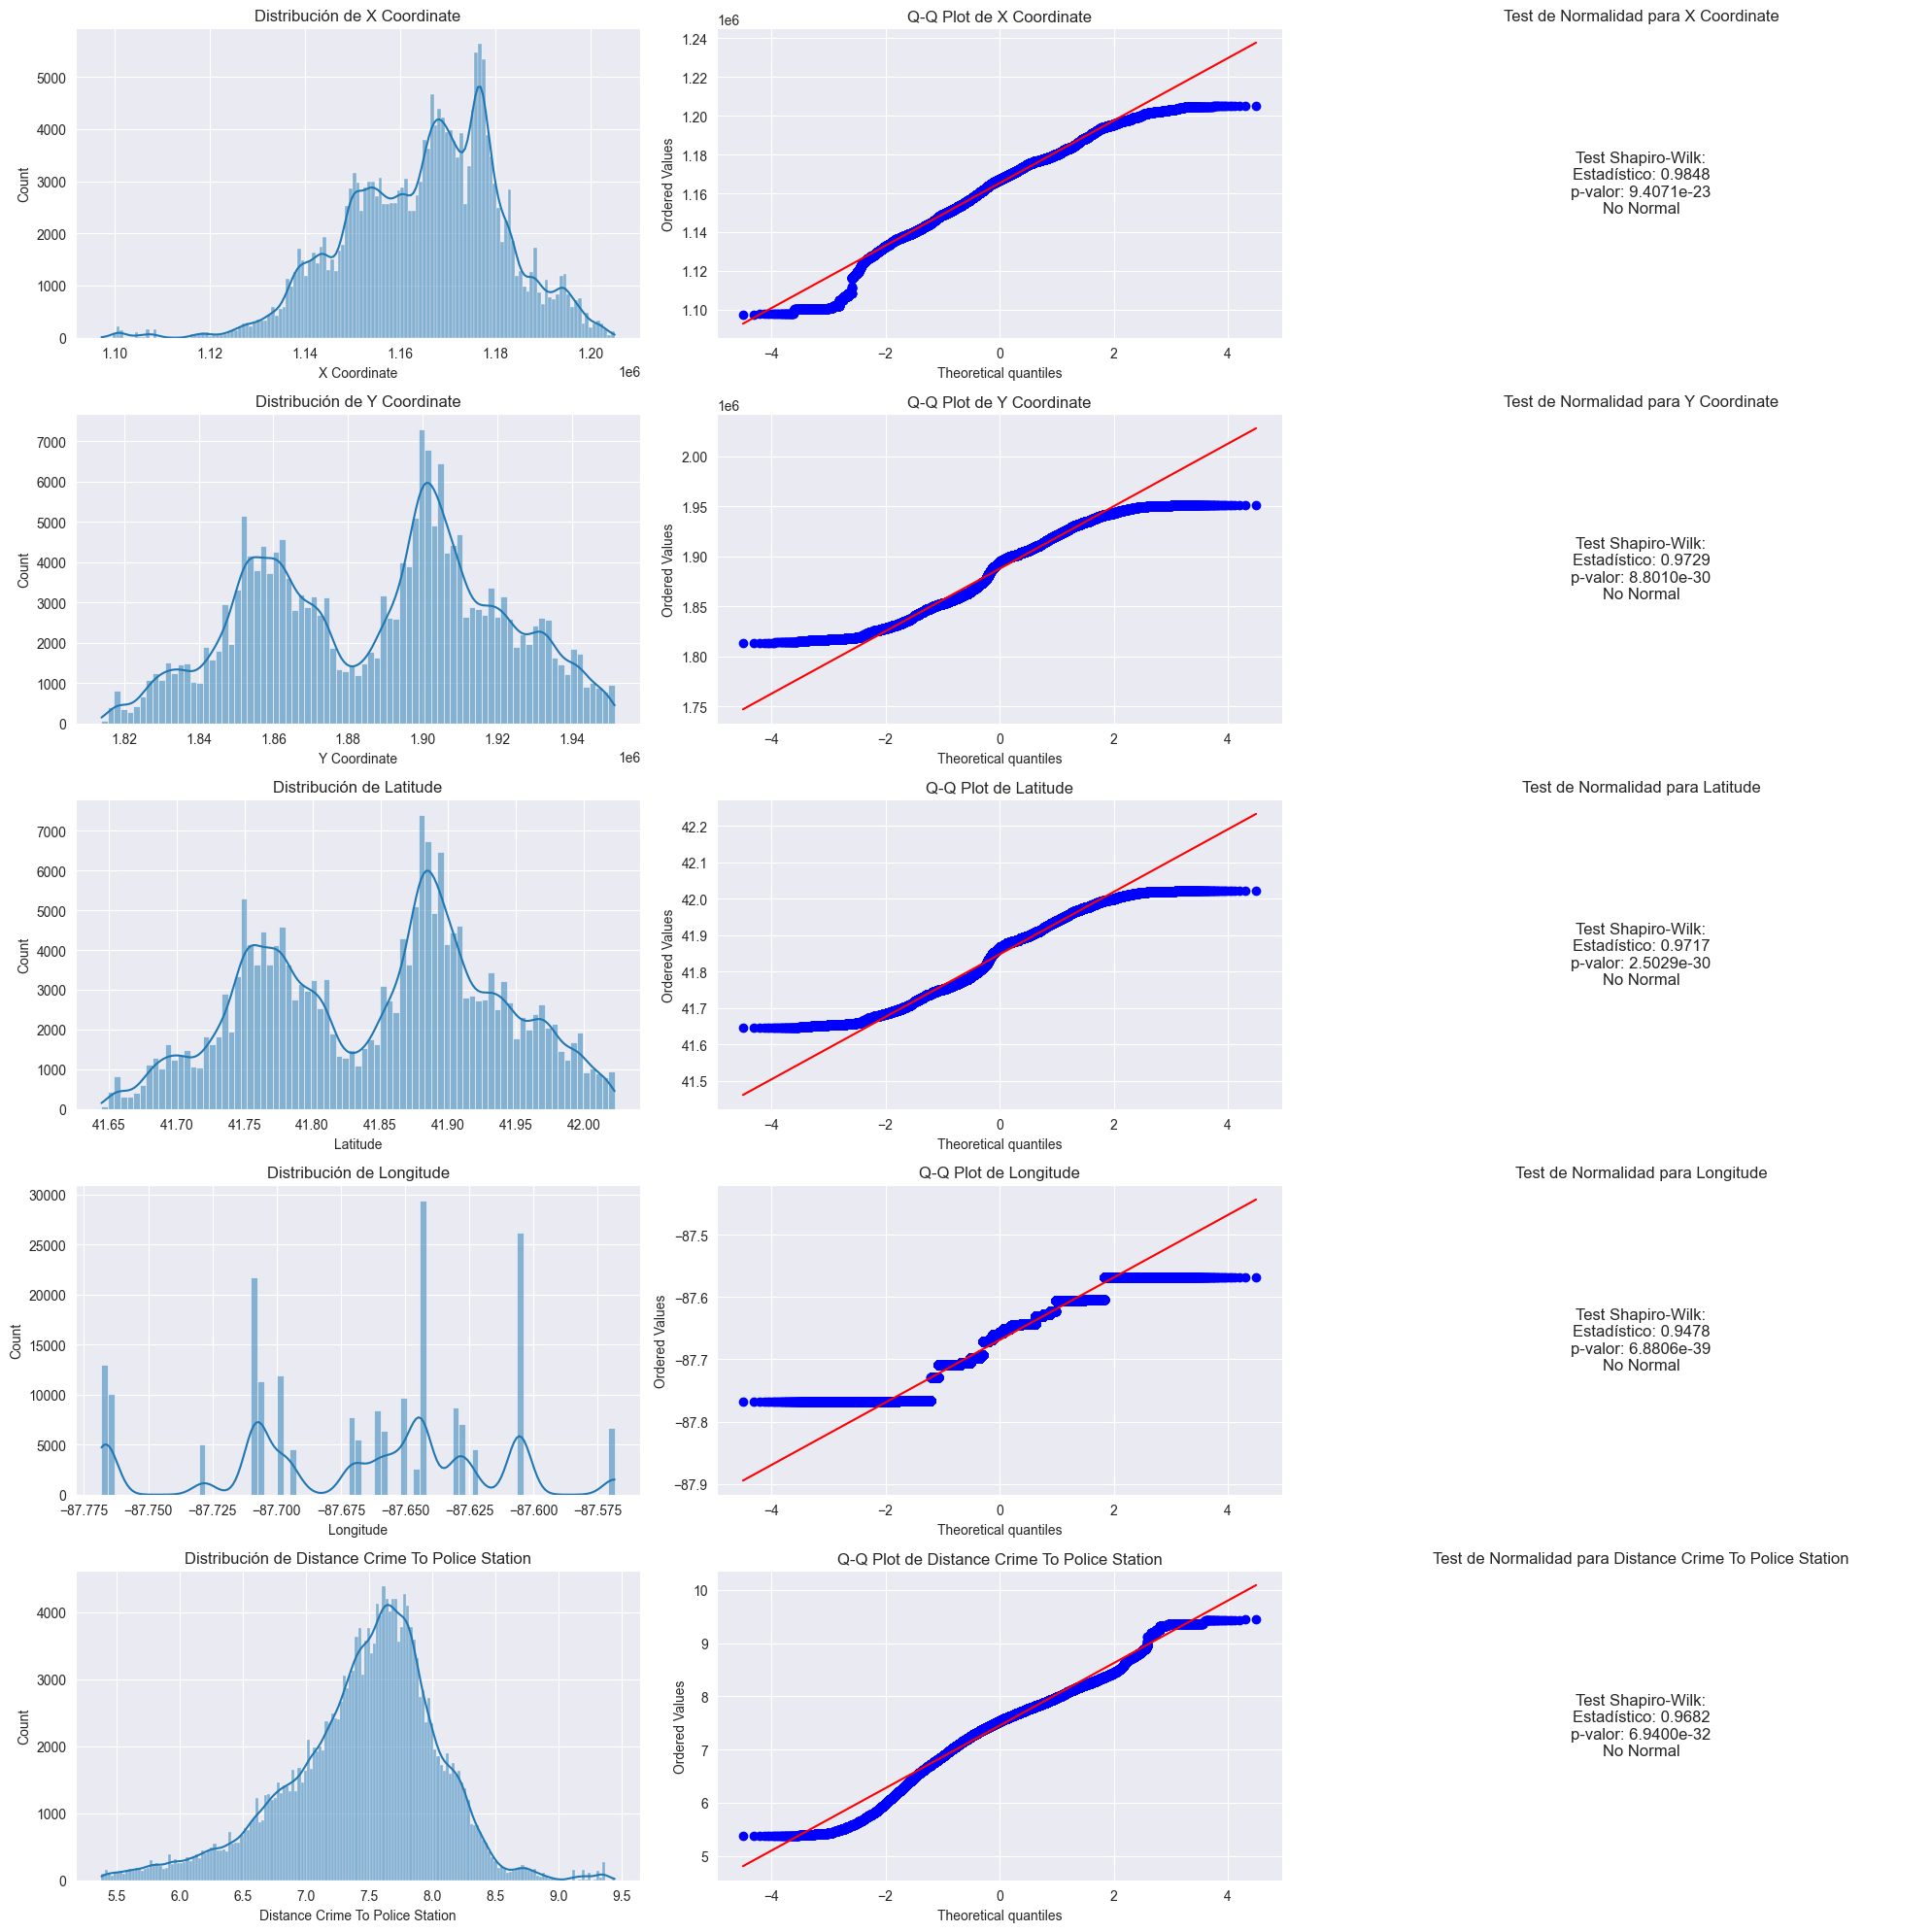

In [69]:
# Verifico la distribución de las coordenadas y la distancia
plt.figure(figsize=(20, 20))  # Aumenté la altura para acomodar 5 variables

# 1. Histogramas para visualizar la distribución
for i, col in enumerate(spatial_columns):
    plt.subplot(5, 3, i*3+1)  # 5 filas (una por variable), 3 columnas (histograma, QQ-plot, test)
    sns.histplot(df_crimes[col], kde=True)
    plt.title(f'Distribución de {col}')

    # 2. QQ-plots para comparar con distribución normal
    plt.subplot(5, 3, i*3+2)
    stats.probplot(df_crimes[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {col}')

    # 3. Test de normalidad Shapiro-Wilk
    stat, p_value = stats.shapiro(df_crimes[col].sample(min(5000, len(df_crimes))))
    plt.subplot(5, 3, i*3+3)
    plt.text(0.5, 0.5, f'Test Shapiro-Wilk:\nEstadístico: {stat:.4f}\np-valor: {p_value:.4e}\n{"Normal" if p_value > 0.05 else "No Normal"}',
             ha='center', va='center', fontsize=12)
    plt.axis('off')
    plt.title(f'Test de Normalidad para {col}')

plt.tight_layout()
plt.show()

En clase vimos dos opciones de normalización/estandarización

1. Estandarización (StandardScaler):
    * Transforma los datos para que tengan media 0 y desviación estándar 1.
    * Útil cuando los datos siguen una distribución aproximadamente normal.
2. Normalización (MinMaxScaler):
    * Escala los datos al rango [0,1] o [-1,1].
    * Útil cuando no se asume una distribución específica.

**Algunas observaciones**:
1. StandardScaler es menos sensible a valores atípicos que MinMaxScaler.
2. Robustez de StandardScaler:
    * Aunque se basa en la media y desviación estándar, StandardScaler puede ser útil incluso cuando los datos no son perfectamente normales.
    * Es más robusto ante valores atípicos que MinMaxScaler.
3. Cuándo usar MinMaxScaler:
    * Si los datos tienen una distribución claramente no normal
    * Si el algoritmo específico requiere datos en un rango acotado (como [0,1])
    * Si la interpretabilidad de los valores escalados es importante

**Existen otras alternativas como**:
1. RobustScaler: Para datos con distribuciones no normales, RobustScaler puede ser más apropiado, ya que usa la mediana y el rango intercuartílico en lugar de la media y desviación estándar.
2. QuantileTransformer: Transforma las características para seguir una distribución específica.

Se podrían explorar también algunas transformaciones específicas para coordenadas geográficas. Las coordenadas geográficas tienen características especiales que pueden beneficiarse de transformaciones específicas:
1. Transformación Haversine
    * Para datos geoespaciales, una transformación común es convertir las coordenadas (latitud, longitud) en distancias relativas a un punto de referencia.
2. Transformación a coordenadas cartesianas
    * Otra opción es transformar las coordenadas geográficas a un sistema cartesiano local.


### Normalización (Min-Max)

In [70]:
# Normalización (Min-Max)
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_subset), columns=df_subset.columns)
print("Normalizado:\n", df_normalized.head())

Normalizado:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      0.830243      0.336434  0.335700   0.812867   
1      0.763869      0.434068  0.433676   0.688712   
2      0.449241      0.284536  0.286167   0.296902   
3      0.807472      0.343695  0.343106   0.812867   
4      0.372423      0.681684  0.683326   0.013137   

   Distance Crime To Police Station  
0                          0.453514  
1                          0.455799  
2                          0.716265  
3                          0.377822  
4                          0.520674  


In [71]:
df_normalized.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000
mean,0.630187,0.535058,0.535364,0.496437,0.509489
std,0.150375,0.229709,0.229959,0.257612,0.146392
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.524890,0.337030,0.337256,0.313793,0.430270
50%,0.646972,0.583284,0.583809,0.556552,0.530124
75%,0.736256,0.701169,0.701890,0.688712,0.603304
max,1.000000,1.000000,1.000000,1.000000,1.000000


### Estandarización (Z-Score)

In [72]:
# Estandarización (Z-Score)
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_subset), columns=df_subset.columns)
print("\nEstandarizado:\n", df_standardized.head())


Estandarizado:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      1.330383     -0.864675 -0.868260   1.228326   
1      0.888992     -0.439643 -0.442201   0.746381   
2     -1.203298     -1.090606 -1.083662  -0.774558   
3      1.178956     -0.833068 -0.836054   1.228326   
4     -1.714142      0.638315  0.643433  -1.876083   

   Distance Crime To Police Station  
0                         -0.382365  
1                         -0.366757  
2                          1.412487  
3                         -0.899415  
4                          0.076405  


In [73]:
df_standardized.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,2.004980e+05,2.004980e+05,2.004980e+05,2.004980e+05,2.004980e+05
mean,-6.162682e-15,8.588970e-16,-1.128298e-13,1.034430e-13,7.082109e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-4.190768e+00,-2.329288e+00,-2.328091e+00,-1.927078e+00,-3.480320e+00
25%,-7.002257e-01,-8.620807e-01,-8.614925e-01,-7.089899e-01,-5.411467e-01
50%,1.116230e-01,2.099446e-01,2.106697e-01,2.333582e-01,1.409571e-01
75%,7.053668e-01,7.231380e-01,7.241591e-01,7.463809e-01,6.408488e-01
max,2.459273e+00,2.024053e+00,2.020526e+00,1.954744e+00,3.350680e+00


### Escalado robusto (RobustScaler)

In [74]:
# Escalado robusto (RobustScaler)
scaler = RobustScaler()
df_robust = pd.DataFrame(scaler.fit_transform(df_subset), columns=df_subset.columns)
print("\nEscalado robusto:\n", df_robust.head())


Escalado robusto:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      0.867079     -0.677900 -0.680433   0.683652   
1      0.553054     -0.409778 -0.411736   0.352503   
2     -0.935492     -0.820424 -0.816278  -0.692549   
3      0.759347     -0.657961 -0.660122   0.683652   
4     -1.298929      0.270228  0.272925  -1.449419   

   Distance Crime To Police Station  
0                         -0.442745  
1                         -0.429540  
2                          1.075749  
3                         -0.880183  
4                         -0.054612  


In [75]:
df_robust.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000
mean,-0.079414,-0.132439,-0.132860,-0.160343,-0.119254
std,0.711446,0.630829,0.630657,0.687112,0.846029
min,-3.060909,-1.601818,-1.601084,-1.484458,-3.063698
25%,-0.577585,-0.676263,-0.676165,-0.647497,-0.577078
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.422415,0.323737,0.323835,0.352503,0.422922
max,1.670221,1.144390,1.141396,1.182781,2.715512


### Escalado con quantiles (QuantileTransformer)

In [76]:
# Escalado con quantiles (QuantileTransformer)
qt_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
df_qt = pd.DataFrame(qt_transformer.fit_transform(df_subset), columns=df_subset.columns)
print("\nEscalado con quantiles:\n", df_qt.head())


Escalado con quantiles:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      1.390900     -0.701720 -0.708223   1.202347   
1      0.954759     -0.313715 -0.317669   0.699108   
2     -1.124945     -1.014649 -1.000414  -0.922330   
3      1.283973     -0.655118 -0.660008   1.202347   
4     -1.691682      0.562356  0.569028  -1.310017   

   Distance Crime To Police Station  
0                         -0.533179  
1                         -0.518519  
2                          1.677630  
3                         -0.929766  
4                         -0.056827  


In [77]:
df_qt.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000
mean,0.013394,-0.020288,-0.020376,0.001768,0.006225
std,0.991553,1.009422,1.009137,1.591545,0.999602
min,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338
25%,-0.651646,-0.699711,-0.699136,-0.565738,-0.664124
50%,0.016358,-0.002448,-0.002469,0.045180,0.014947
75%,0.680325,0.664010,0.663196,0.699108,0.681226
max,5.199338,5.199338,5.199338,5.199338,5.199338


### Comparamos resultados

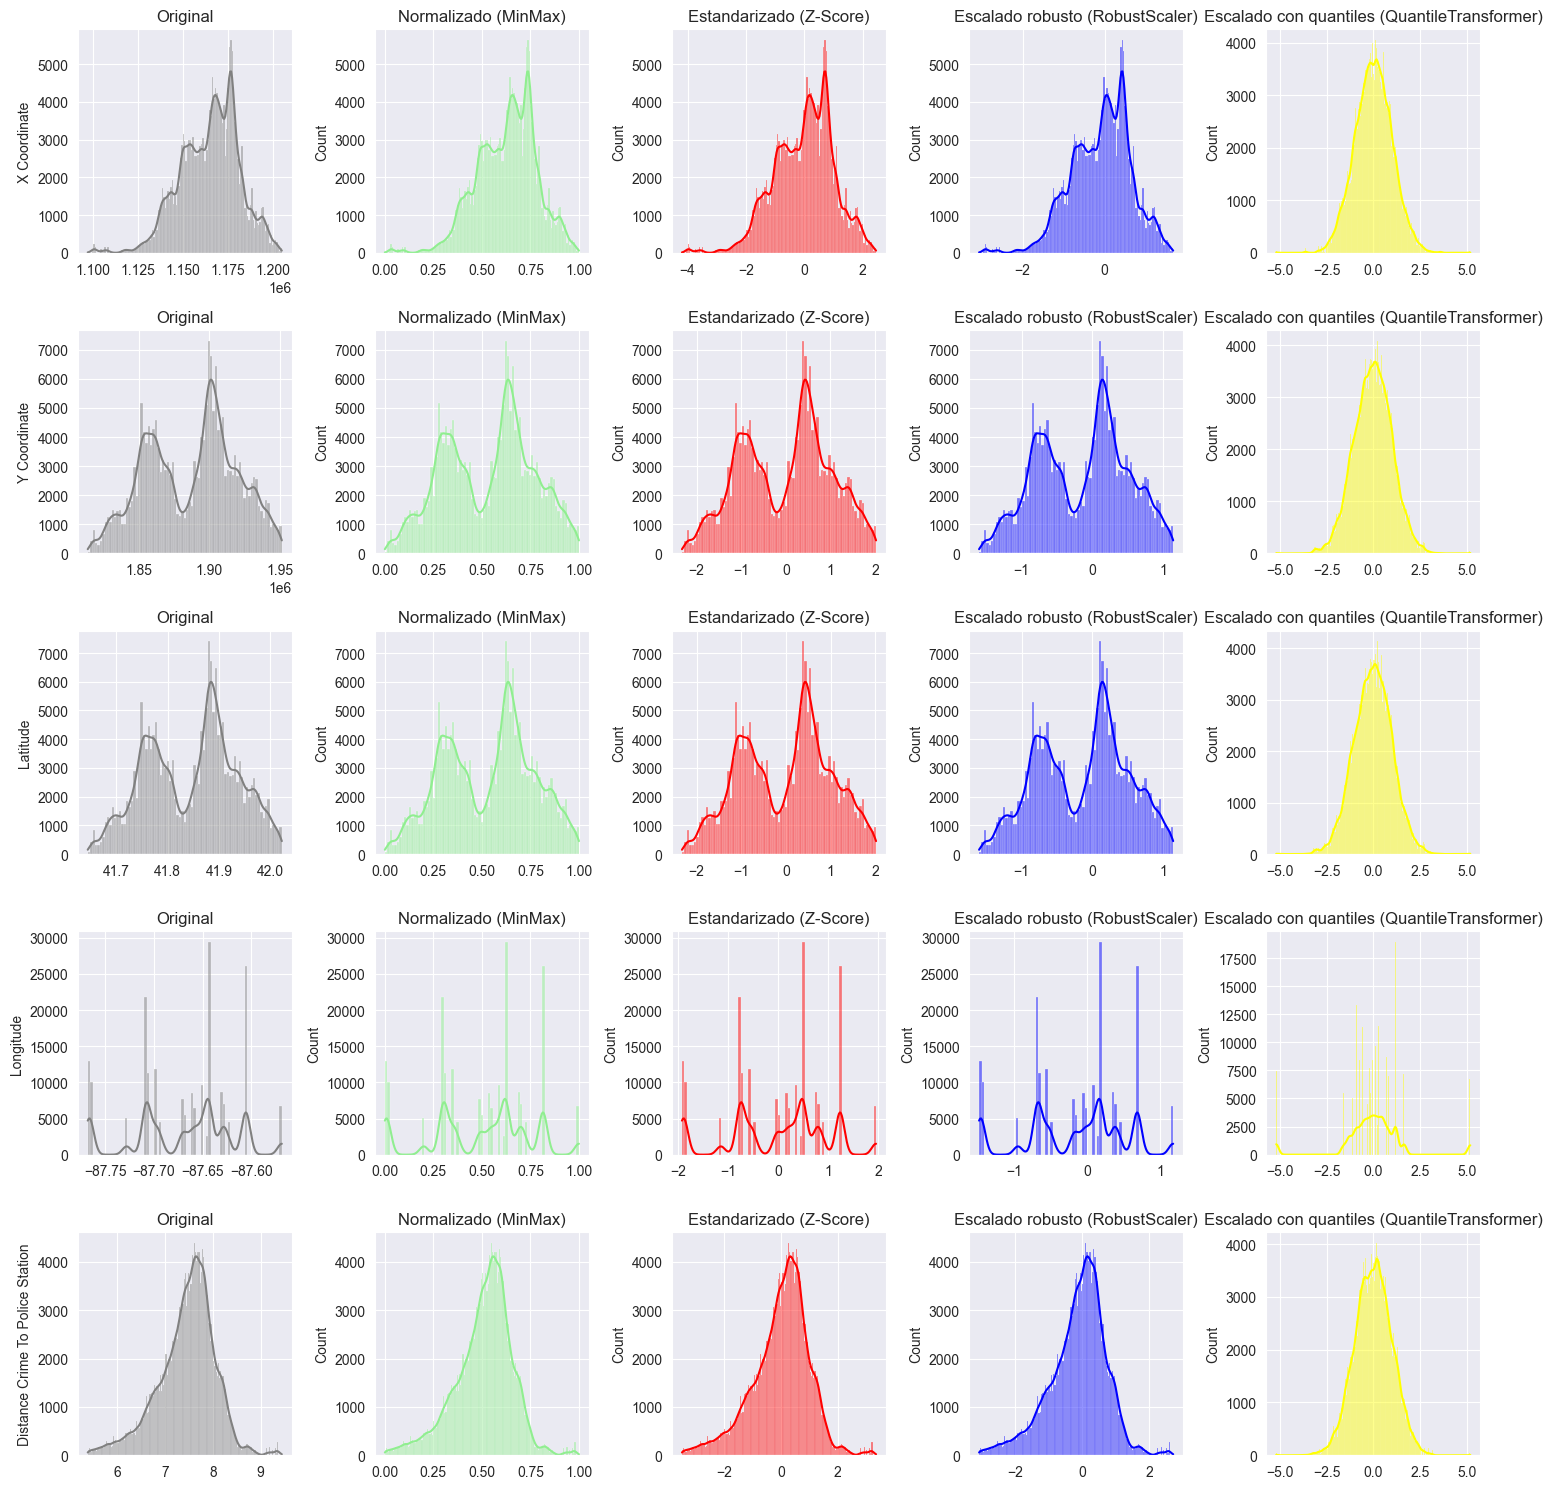

In [78]:
# Gráfico
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 15))
titles = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)", "Escalado robusto (RobustScaler)", "Escalado con quantiles (QuantileTransformer)"]

# Recorrer cada variable y graficarla en las tres columnas
for i, col in enumerate(spatial_columns):
    sns.histplot(df_subset[col], kde=True, ax=axes[i, 0], color="gray")
    sns.histplot(df_normalized[col], kde=True, ax=axes[i, 1], color="lightgreen")
    sns.histplot(df_standardized[col], kde=True, ax=axes[i, 2], color="red")
    sns.histplot(df_robust[col], kde=True, ax=axes[i, 3], color="blue")
    sns.histplot(df_qt[col], kde=True, ax=axes[i, 4], color="yellow")

    # Etiquetas
    axes[i, 0].set_ylabel(col)
    for j in range(5):
        axes[i, j].set_xlabel("")
        axes[i, j].set_title(titles[j])

# Ajustar el layout
plt.tight_layout()
plt.show()

## Salvamos en un archivo

In [81]:
# df_crimes[spatial_columns] = df_standardized[spatial_columns]
# Recorrer cada variable y reemplazarla en dataset original
for i, col in enumerate(spatial_columns):
    df_crimes[f"{col}_standardized"] = df_standardized[col]

df_crimes.drop(columns=spatial_columns, inplace=True)
df_crimes.describe()

,Beat,Ward,Community Area,Day_sin,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Day Time_Afternoon,Day Time_Early Morning,...,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq,X Coordinate_standardized,Y Coordinate_standardized,Latitude_standardized,Longitude_standardized,Distance Crime To Police Station_standardized
count,200498.000000,200498.000000,200498.000000,2.004980e+05,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,...,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,2.004980e+05,2.004980e+05,2.004980e+05,2.004980e+05,2.004980e+05
mean,1155.734835,23.121243,36.333375,6.370059e-03,0.252965,0.246347,0.271614,0.229075,0.310083,0.198980,...,0.135137,0.115559,0.048246,0.052476,0.052476,-6.162682e-15,8.588970e-16,-1.128298e-13,1.034430e-13,7.082109e-16
std,708.424783,13.930460,21.588020,7.081135e-01,0.434712,0.430884,0.444793,0.420238,0.462528,0.399234,...,0.106745,0.074246,0.010772,0.022307,0.022307,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,111.000000,1.000000,1.000000,-9.749279e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000005,0.000010,0.000050,0.013172,0.013172,-4.190768e+00,-2.329288e+00,-2.328091e+00,-1.927078e+00,-3.480320e+00
25%,533.000000,10.000000,22.000000,-7.818315e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.023656,0.055592,0.039801,0.035931,0.035931,-7.002257e-01,-8.620807e-01,-8.614925e-01,-7.089899e-01,-5.411467e-01
50%,1033.000000,23.000000,32.000000,-2.449294e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.121438,0.085467,0.051572,0.048115,0.048115,1.116230e-01,2.099446e-01,2.106697e-01,2.333582e-01,1.409571e-01
75%,1731.000000,34.000000,53.000000,7.818315e-01,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.273399,0.149203,0.053796,0.066335,0.066335,7.053668e-01,7.231380e-01,7.241591e-01,7.463809e-01,6.408488e-01
max,2535.000000,50.000000,77.000000,9.749279e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.273399,0.231090,0.067287,0.094475,0.094475,2.459273e+00,2.024053e+00,2.020526e+00,1.954744e+00,3.350680e+00


In [82]:
df_crimes.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv", index=False)